# Fake News Detection using NLP and Logistic Regression

Welcome to this beginner-friendly Machine Learning project! Our goal is to build a text classification model that can predict whether a given news article is **Fake (0)** or **Real (1)**.

### Project Workflow:
1. **Data Loading**: Load the `Fake.csv` and `True.csv` datasets and combine them.
2. **Data Preprocessing**: Clean the text data (lowercasing, removing punctuation and stopwords, stemming).
3. **Feature Extraction**: Convert text to numerical data using TF-IDF.
4. **Model Training**: Train a Logistic Regression model.
5. **Evaluation**: Check the model's accuracy, precision, recall, and visualize the confusion matrix.
6. **Predictions**: Test the model on unseen data.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download NLTK resources if not already present
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nirod\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nirod\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nirod\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 2. Load the Dataset
We are using the `Fake.csv` and `True.csv` datasets. We will load both, assign a label (`0` for Fake, `1` for True), and then combine them into a single dataframe.

In [2]:
# Load datasets
fake_df = pd.read_csv('../data/Fake.csv')
true_df = pd.read_csv('../data/True.csv')

# Add labels
fake_df['label'] = 0
true_df['label'] = 1

# Combine datasets
df = pd.concat([fake_df, true_df], axis=0).reset_index(drop=True)

# Shuffle the dataset so that Fake and True news are mixed
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the first few rows
display(df.head())

# Check class distribution
print("\nClass Distribution:\n", df['label'].value_counts())

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1



Class Distribution:
 label
0    23481
1    21417
Name: count, dtype: int64


## 3. Data Preprocessing
Machine learning models cannot understand raw text. We need to clean it first.

In [3]:
# Combine title and text for more information
df['full_text'] = df['title'] + " " + df['text']

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
        
    # Lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords & apply Stemming
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    
    cleaned_tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    
    return " ".join(cleaned_tokens)

print("Preprocessing text... this may take a few minutes for a large dataset.")
# Apply preprocessing
df['cleaned_text'] = df['full_text'].apply(preprocess_text)

print("\nOriginal:\n", df['full_text'].iloc[0][:500])
print("\nCleaned :\n", df['cleaned_text'].iloc[0][:500])

Preprocessing text... this may take a few minutes for a large dataset.

Original:
 Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washingto

Cleaned :
 ben stein call 9th circuit court commit ‘ coup ’ état ’ constitut 21st centuri wire say ben stein reput professor pepperdin univers also hollywood fame appear tv show film ferri bueller day made provoc statement judg jeanin pirro show recent discuss halt impos presid trump execut order travel stein refer judgement 9th circuit court washington state coup tat execut branch constitut stein went call judg

## 4. Feature Extraction
We use **TF-IDF** (Term Frequency-Inverse Document Frequency) to convert our cleaned text into a numerical format.

In [4]:
# Define features (X) and target (y)
X = df['cleaned_text']
y = df['label']

# Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize TF-IDF Vectorizer (limiting to top 5000 features for performance)
vectorizer = TfidfVectorizer(max_features=5000)

# Fit on training data and transform both train and test data
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Shape of X_train_tfidf:", X_train_tfidf.shape)

Shape of X_train_tfidf: (35918, 5000)


## 5. Model Training
We will use **Logistic Regression**, which is a powerful and easy-to-understand model for binary classification tasks.

In [5]:
model = LogisticRegression(max_iter=500)
model.fit(X_train_tfidf, y_train)

print("Model training complete!")

Model training complete!


## 6. Model Evaluation
Let's see how our model performs on the test set.

In [6]:
y_pred = model.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9849

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.99      0.98      8980
weighted avg       0.98      0.98      0.98      8980



### Confusion Matrix Visualization

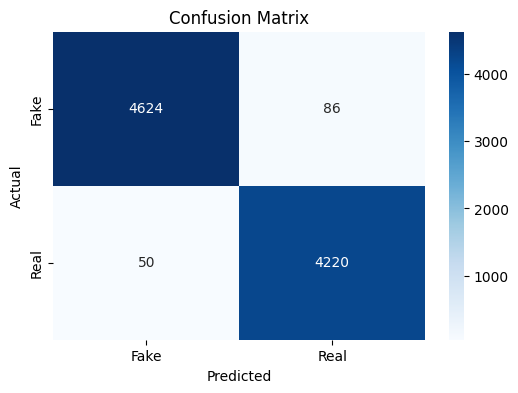

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 7. Save the Model
We save the trained model and vectorizer so we can use them later without retraining.

In [8]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(model, '../models/model.pkl')
joblib.dump(vectorizer, '../models/vectorizer.pkl')

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


## 8. Making Predictions on New Data
Let's test our model on some unseen, completely new text.

In [9]:
def predict_news(text):
    # Preprocess
    cleaned = preprocess_text(text)
    # Vectorize
    vectorized = vectorizer.transform([cleaned])
    # Predict
    pred = model.predict(vectorized)[0]
    prob = model.predict_proba(vectorized)[0]
    
    label = "Real" if pred == 1 else "Fake"
    confidence = prob[pred] * 100
    
    print(f"News: '{text}'")
    print(f"Prediction: {label} (Confidence: {confidence:.2f}%)\n")

sample_1 = "Scientists successfully teleport an apple across the laboratory."
sample_2 = "The central bank announced a new set of interest rates to combat inflation."

predict_news(sample_1)
predict_news(sample_2)

News: 'Scientists successfully teleport an apple across the laboratory.'
Prediction: Fake (Confidence: 81.28%)

News: 'The central bank announced a new set of interest rates to combat inflation.'
Prediction: Fake (Confidence: 59.93%)

